# MobileNet+YOLOv8m Model Evaluation

This notebook evaluates the MobileNet+YOLOv8m model trained on YOLOv8m-detected face crops.
- **Model**: face_mask_mobilenet_yolov8m_best.h5
- **Purpose**: Compare performance when the model is trained on realistic YOLOv8m detections instead of ground truth boxes
- **Evaluation**: Performance metrics on test set with ground truth bounding boxes for consistency

## Setup and Imports

In [11]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Define Paths and Load Model

### How to Calculate Model Parameters

**Formula for Dense/Fully Connected Layers:**
```
Parameters = (input_size × output_size) + output_size
           = (input_size × output_size) + bias_terms
```

**Example: Dense(256) after 1280 inputs:**
```
Parameters = (1280 × 256) + 256 = 327,936
```

**Formula for Convolutional Layers:**
```
Parameters = (kernel_height × kernel_width × input_channels × output_channels) + output_channels
```

**Example: Conv2D(3×3, input=32, output=64):**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 18,496
```

**Formula for Batch Normalization:**
```
Parameters = 2 × num_features  (scale + shift parameters)
           + 2 × num_features  (running mean + variance, not trainable)
```

**Example: BatchNorm(256 features):**
```
Parameters = 2 × 256 = 512 (trainable)
```

**Layers with NO Parameters:**
- Activation layers (ReLU, Sigmoid, etc.)
- Dropout layers
- GlobalAveragePooling layers
- Max/Average Pooling layers


In [12]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
MODEL_PATH = BASE_DIR / 'models' / 'face_mask_mobilenet_yolov8m_best.h5'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

# Model input size
IMG_SIZE = 192

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

Model path: /Users/khoanguyen/Workspace/UIT/face_mask_detection/models/face_mask_mobilenet_yolov8m_best.h5
Model exists: True
Test images directory exists: True
Test labels directory exists: True


In [13]:
# Load model
print("Loading MobileNet+YOLOv8m model...")
model = keras.models.load_model(str(MODEL_PATH), compile=False)
print("Model loaded successfully!")
print(f"Model summary:")
model.summary()

Loading MobileNet+YOLOv8m model...
Model loaded successfully!
Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,739 (10.00 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

## Data Preparation

In [14]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

# Function to convert YOLO format to pixel coordinates
def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox (normalized center_x, center_y, width, height) to pixel coordinates (x1, y1, x2, y2)"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    
    # Convert from normalized to pixel coordinates
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    # Calculate top-left and bottom-right corners
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    # Clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

print("Helper functions defined")
print(f"Sample test images:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 578 test images
Helper functions defined
Sample test images:
  0020.jpg
  0049.jpg
  0054.jpg


## Model Evaluation

In [15]:
# Run predictions on test set
print("Running MobileNet+YOLOv8m predictions on test set using ground truth bounding boxes...")

y_true = []
y_pred = []
confidences = []

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Process each ground truth bounding box
    for gt_class, center_x, center_y, bbox_w, bbox_h in gt_labels:
        # Convert YOLO format to pixel coordinates
        x1, y1, x2, y2 = convert_yolo_to_pixel_coords((center_x, center_y, bbox_w, bbox_h), img_w, img_h)
        
        # Crop face region
        face = img[y1:y2, x1:x2]
        if face.size == 0:
            continue
        
        # Preprocess for MobileNet
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        face_normalized = face_rgb / 255.0
        face_batch = np.expand_dims(face_normalized, axis=0)
        
        # Predict
        pred = model.predict(face_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        confidence = np.max(pred[0])
        
        y_true.append(gt_class)
        y_pred.append(pred_class)
        confidences.append(confidence)

print(f"\nTotal predictions: {len(y_pred)}")
print(f"Total ground truth: {len(y_true)}")

Running MobileNet+YOLOv8m predictions on test set using ground truth bounding boxes...


100%|██████████| 578/578 [00:45<00:00, 12.69it/s]


Total predictions: 1392
Total ground truth: 1392


## Calculate Metrics

In [16]:
# Calculate overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

print("\n" + "="*80)
print("MOBILENET+YOLOV8M MODEL - OVERALL METRICS")
print("="*80)
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1-Score:        {f1:.4f}")
print(f"Avg Confidence:  {np.mean(confidences):.4f}")

print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(precision_per_class):
        print(f"\n{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall:    {recall_per_class[i]:.4f}")
        print(f"  F1-Score:  {f1_per_class[i]:.4f}")


MOBILENET+YOLOV8M MODEL - OVERALL METRICS
Accuracy:        0.8757
Precision:       0.8847
Recall:          0.8757
F1-Score:        0.8768
Avg Confidence:  1.7789

PER-CLASS METRICS

With Mask:
  Precision: 0.9522
  Recall:    0.9005
  F1-Score:  0.9256

Without Mask:
  Precision: 0.6677
  Recall:    0.8704
  F1-Score:  0.7557

Mask Weared Incorrect:
  Precision: 0.3600
  Recall:    0.2250
  F1-Score:  0.2769


## Visualizations

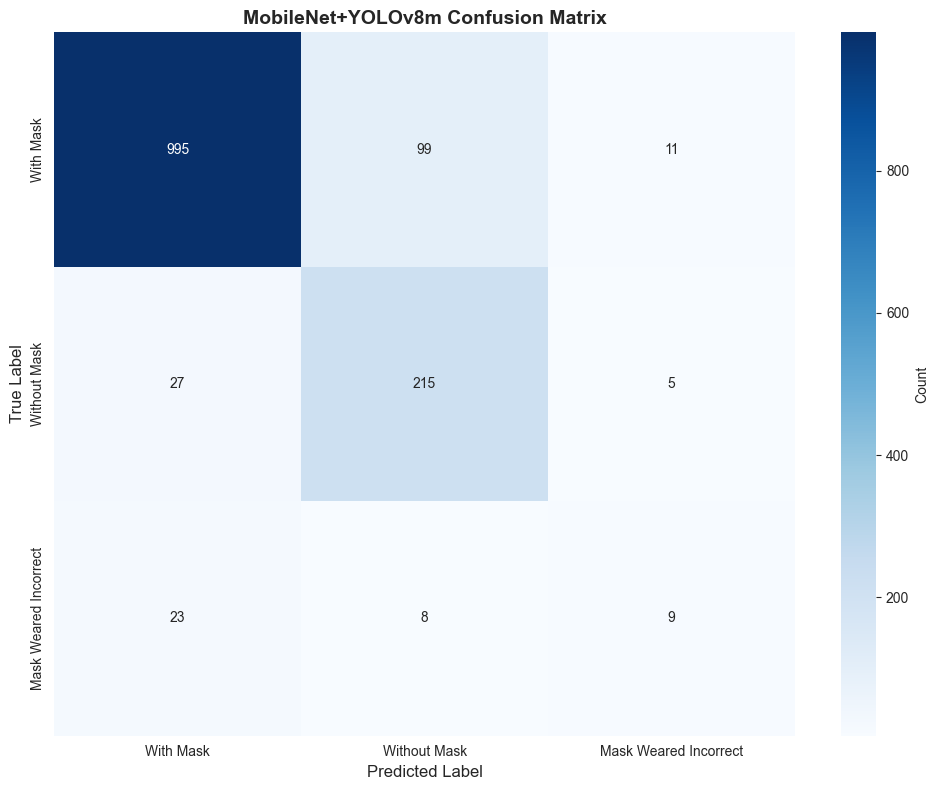

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
ax.set_title('MobileNet+YOLOv8m Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

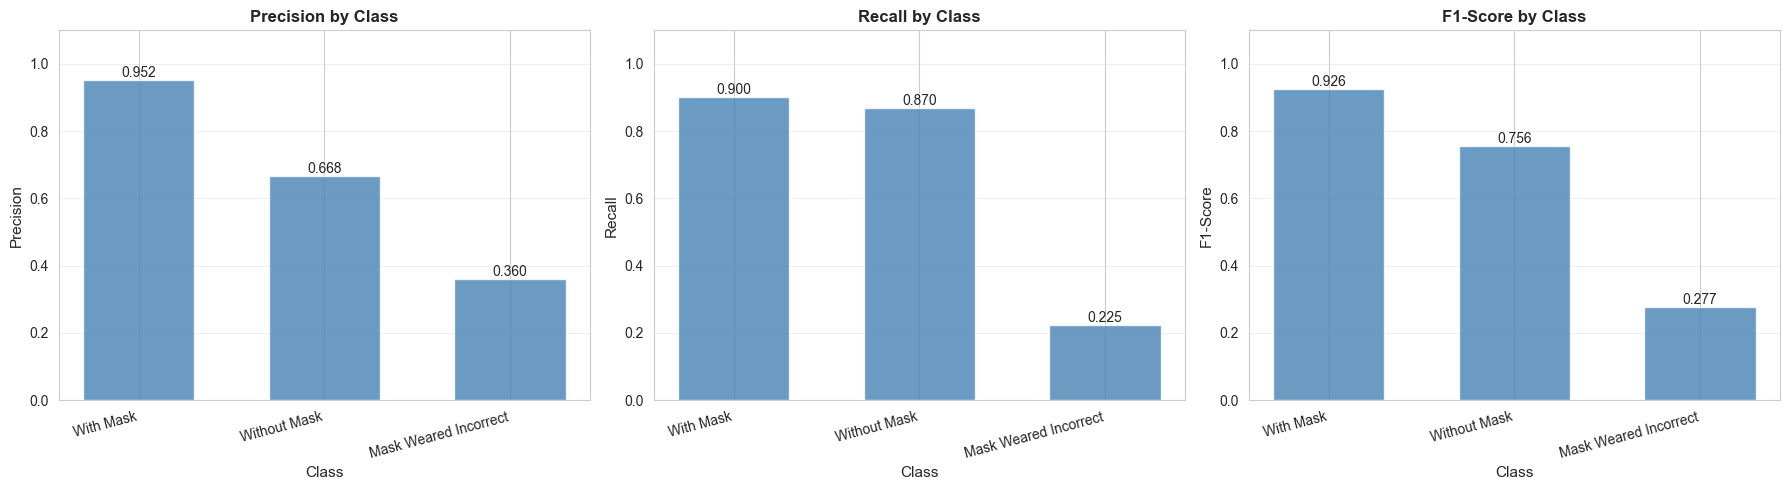

In [18]:
# Per-class metrics visualization
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [precision_per_class, recall_per_class, f1_per_class]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric_name, metric_vals) in enumerate(zip(metrics_names, metrics_values)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.6
    
    # Ensure all classes are represented
    plot_vals = np.zeros(len(CLASS_NAMES))
    for i in range(len(CLASS_NAMES)):
        if i < len(metric_vals):
            plot_vals[i] = metric_vals[i]
    
    bars = ax.bar(x, plot_vals, width, alpha=0.8, color='steelblue')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} by Class', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

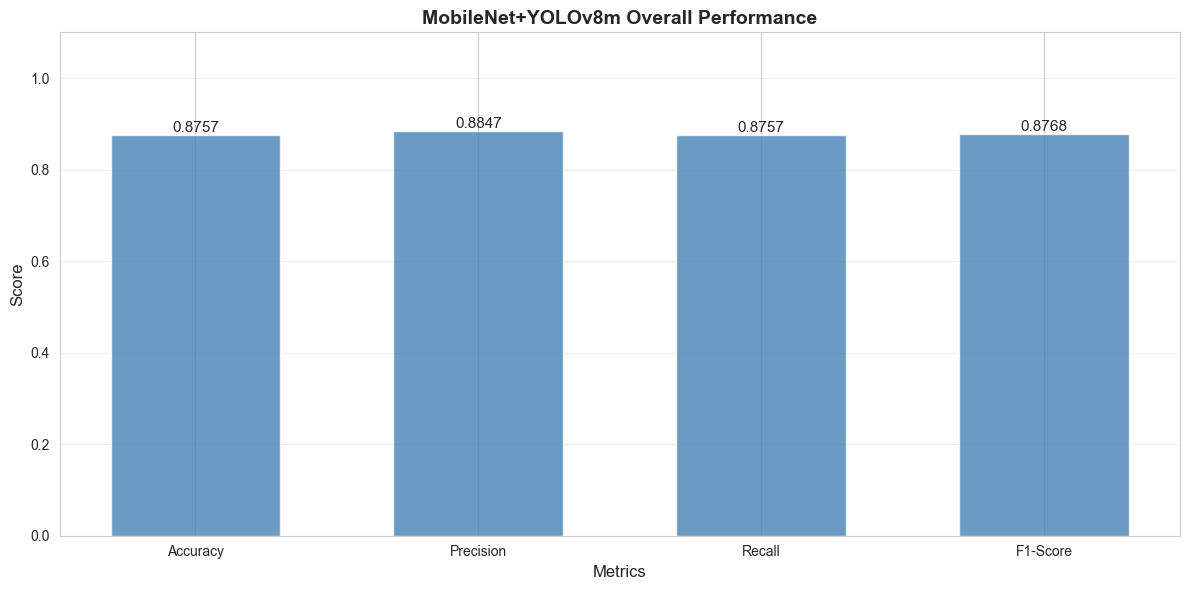

In [19]:
# Overall metrics bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_names))
width = 0.6

bars = ax.bar(x, metrics_values, width, alpha=0.8, color='steelblue')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('MobileNet+YOLOv8m Overall Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

## Detailed Classification Report

In [20]:
print("\n" + "="*80)
print("MOBILENET+YOLOV8M CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


MOBILENET+YOLOV8M CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.95      0.90      0.93      1105
         Without Mask       0.67      0.87      0.76       247
Mask Weared Incorrect       0.36      0.23      0.28        40

             accuracy                           0.88      1392
            macro avg       0.66      0.67      0.65      1392
         weighted avg       0.88      0.88      0.88      1392

